In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score, f1_score
from sklearn.metrics import precision_score, recall_score
import seaborn as sns


In [ ]:
# Impostiamo uno stile grafico coerente
plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)

# Creiamo un dataset sbilanciato di diagnosi medica (20% positivi, 80% negativi)
# X rappresenta i parametri clinici dei pazienti, y rappresenta la diagnosi (0=sano, 1=malato)
X, y = make_classification(n_samples=1000, n_features=10, n_informative=8,
                          n_redundant=2, n_clusters_per_class=2, weights=[0.8, 0.2],
                          random_state=42)

# Dividiamo in training e test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Creiamo e alleniamo il modello di regressione logistica
model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)

# Effettuiamo predizioni sia di classe che di probabilità
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]  # Prendiamo solo le probabilità della classe positiva


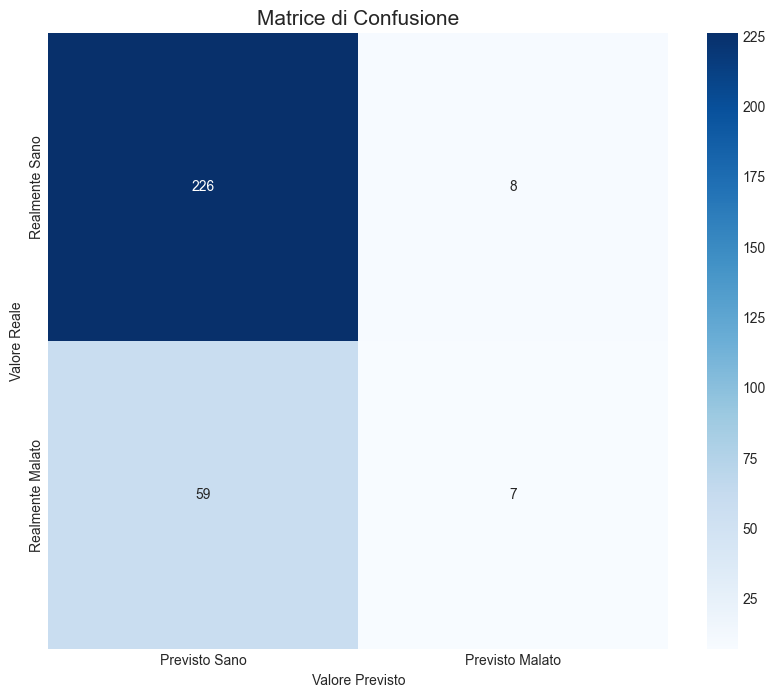

True Negatives (TN): 226
False Positives (FP): 8
False Negatives (FN): 59
True Positives (TP): 7


In [4]:
# 1. MATRICE DI CONFUSIONE
conf_matrix = confusion_matrix(y_test, y_pred)

# Visualizziamo la matrice di confusione
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Previsto Sano', 'Previsto Malato'],
            yticklabels=['Realmente Sano', 'Realmente Malato'])
plt.ylabel('Valore Reale')
plt.xlabel('Valore Previsto')
plt.title('Matrice di Confusione', fontsize=15)
plt.show()

# Estraiamo i valori dalla matrice di confusione
tn, fp, fn, tp = conf_matrix.ravel()
print(f"True Negatives (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP): {tp}")


In [5]:
# 2. METRICHE DI VALUTAZIONE
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
f2 = (5 * precision * recall) / (4 * precision + recall)
f0_5 = (1.25 * precision * recall) / (0.25 * precision + recall)

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"F2 Score: {f2:.4f}")
print(f"F0.5 Score: {f0_5:.4f}")



Accuracy: 0.7767
Precision: 0.4667
Recall: 0.1061
F1 Score: 0.1728
F2 Score: 0.1254
F0.5 Score: 0.2778


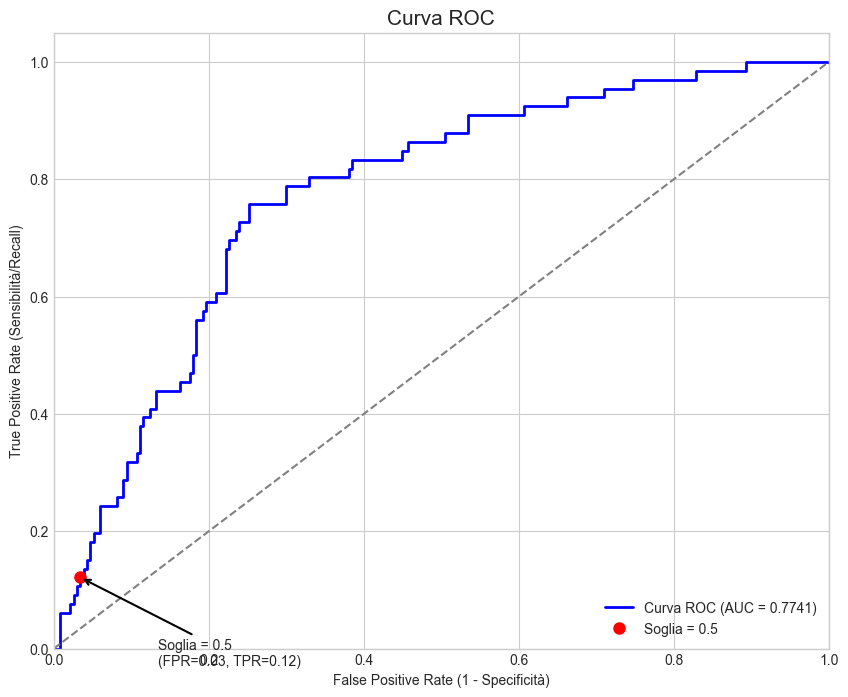

In [6]:
# 3. CURVA ROC E AUC
# Calcoliamo i valori per la curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc = roc_auc_score(y_test, y_pred_proba)

# Visualizziamo la curva ROC
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'Curva ROC (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificità)')
plt.ylabel('True Positive Rate (Sensibilità/Recall)')
plt.title('Curva ROC', fontsize=15)
plt.legend(loc="lower right")
plt.grid(True)

# Aggiungiamo la soglia di default (0.5) sulla curva ROC
idx = np.abs(thresholds - 0.5).argmin()
plt.plot(fpr[idx], tpr[idx], 'ro', markersize=8, label=f'Soglia = 0.5')
plt.annotate(f'Soglia = 0.5\n(FPR={fpr[idx]:.2f}, TPR={tpr[idx]:.2f})',
             xy=(fpr[idx], tpr[idx]), xytext=(fpr[idx]+0.1, tpr[idx]-0.15),
             arrowprops=dict(arrowstyle='->', lw=1.5))
plt.legend(loc="lower right")
plt.show()


c:\Users\Acer\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


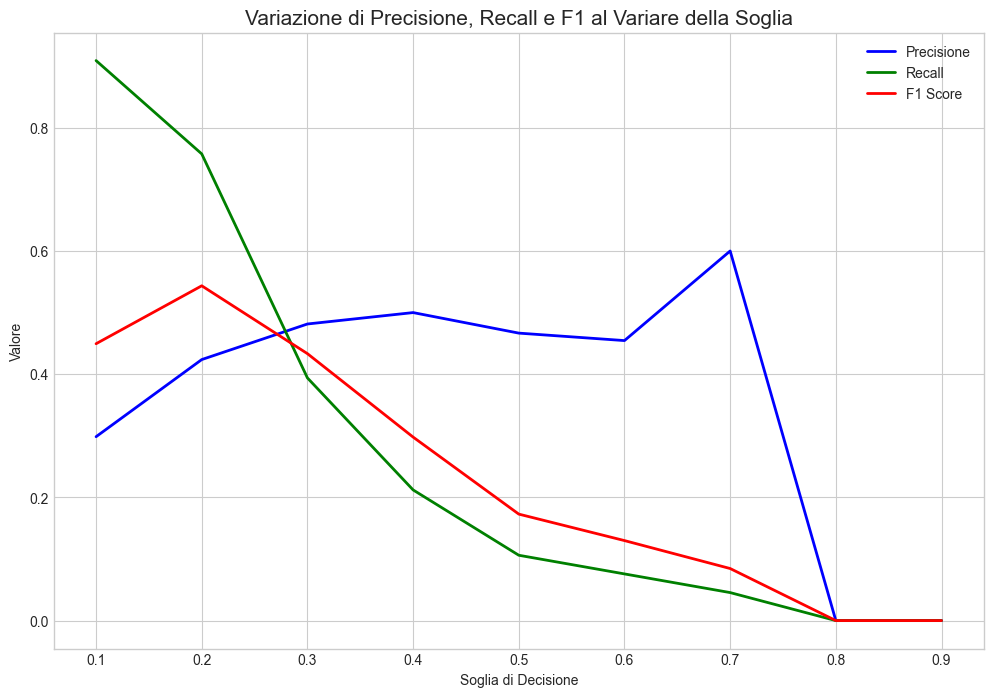

In [7]:
# 4. ANALISI DELLE SOGLIE
# Calcoliamo precisione, recall e F1 per varie soglie
thresholds_to_try = np.arange(0.1, 1.0, 0.1)
threshold_metrics = []

for threshold in thresholds_to_try:
    y_pred_threshold = (y_pred_proba >= threshold).astype(int)
    prec = precision_score(y_test, y_pred_threshold)
    rec = recall_score(y_test, y_pred_threshold)
    f1_val = f1_score(y_test, y_pred_threshold)
    threshold_metrics.append([threshold, prec, rec, f1_val])

threshold_df = pd.DataFrame(threshold_metrics, 
                           columns=['Soglia', 'Precisione', 'Recall', 'F1'])

# Visualizziamo come cambiano le metriche al variare della soglia
plt.figure(figsize=(12, 8))
plt.plot(threshold_df['Soglia'], threshold_df['Precisione'], 'b-', lw=2, label='Precisione')
plt.plot(threshold_df['Soglia'], threshold_df['Recall'], 'g-', lw=2, label='Recall')
plt.plot(threshold_df['Soglia'], threshold_df['F1'], 'r-', lw=2, label='F1 Score')
plt.xlabel('Soglia di Decisione')
plt.ylabel('Valore')
plt.title('Variazione di Precisione, Recall e F1 al Variare della Soglia', fontsize=15)
plt.grid(True)
plt.legend()
plt.show()



Soglia ottimale per F1: 0.20
F1 Score ottimale: 0.5435


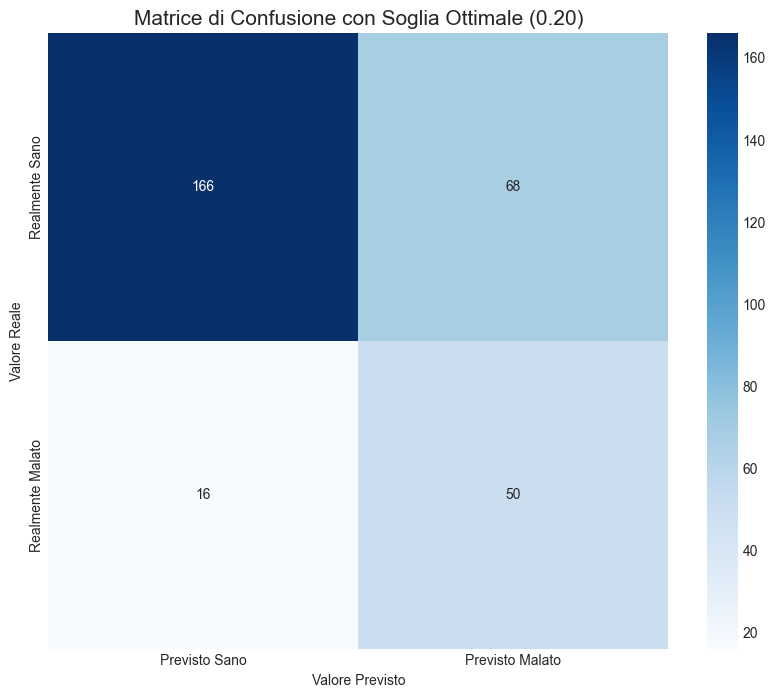

In [8]:
# Troviamo la soglia ottimale per F1
optimal_idx = threshold_df['F1'].idxmax()
optimal_threshold = threshold_df.loc[optimal_idx, 'Soglia']
optimal_f1 = threshold_df.loc[optimal_idx, 'F1']

print(f"\nSoglia ottimale per F1: {optimal_threshold:.2f}")
print(f"F1 Score ottimale: {optimal_f1:.4f}")

# Ricalcoliamo le predizioni e la matrice di confusione con la soglia ottimale
y_pred_optimal = (y_pred_proba >= optimal_threshold).astype(int)
conf_matrix_optimal = confusion_matrix(y_test, y_pred_optimal)

# Visualizziamo la matrice di confusione ottimizzata
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix_optimal, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Previsto Sano', 'Previsto Malato'],
            yticklabels=['Realmente Sano', 'Realmente Malato'])
plt.ylabel('Valore Reale')
plt.xlabel('Valore Previsto')
plt.title(f'Matrice di Confusione con Soglia Ottimale ({optimal_threshold:.2f})', fontsize=15)
plt.show()


In [9]:
# Confrontiamo le metriche prima e dopo l'ottimizzazione della soglia
tn_opt, fp_opt, fn_opt, tp_opt = conf_matrix_optimal.ravel()
precision_opt = tp_opt / (tp_opt + fp_opt) if (tp_opt + fp_opt) > 0 else 0
recall_opt = tp_opt / (tp_opt + fn_opt) if (tp_opt + fn_opt) > 0 else 0
f1_opt = 2 * (precision_opt * recall_opt) / (precision_opt + recall_opt) if (precision_opt + recall_opt) > 0 else 0

print("\nConfrontando le metriche:")
print(f"{'Metrica':<15} {'Soglia Default (0.5)':<20} {'Soglia Ottimale ('+str(optimal_threshold)+')':<20}")
print(f"{'-'*60}")
print(f"{'Precision':<15} {precision:<20.4f} {precision_opt:<20.4f}")
print(f"{'Recall':<15} {recall:<20.4f} {recall_opt:<20.4f}")
print(f"{'F1 Score':<15} {f1:<20.4f} {f1_opt:<20.4f}")



Confrontando le metriche:
Metrica         Soglia Default (0.5) Soglia Ottimale (0.2)
------------------------------------------------------------
Precision       0.4667               0.4237              
Recall          0.1061               0.7576              
F1 Score        0.1728               0.5435              
